# Análisis de datos - TP Individual

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import kagglehub
from scipy import stats as st
from scipy.stats import describe

# Descargamos dataset

In [81]:
# Download latest version
path = kagglehub.dataset_download("jklol86/employee-burnout-and-turnover-prediction-800k")

print("Path to dataset files:", path)

Path to dataset files: /home/jbmild/.cache/kagglehub/datasets/jklol86/employee-burnout-and-turnover-prediction-800k/versions/3


## Cargamos el dataframe desde el dataset

In [82]:
df = pd.read_json(path + "/synthetic-employee-dataset.json")

df.head()

,employee_id,role,job_level,department,tenure_months,salary,performance_score,satisfaction_score,workload_score,team_sentiment,...,goal_achievement_rate,stress_level,burnout_risk,left_company,turnover_reason,risk_factors_summary,turnover_probability_generated,persona_name,role_complexity_score,career_progression_score
0,SYN_00000000,,Mid,Research & Development,169,79704.579059,0.632482,0.623746,0.758117,0.662335,...,0.632482,0.908992,0.866643,False,Not Applicable,Severe Burnout Risk,0.290979,ChangeResistor,0.2,1.000000
1,SYN_00000001,Customer Success Manager,Manager,Research & Development,54,29694.288831,0.538587,0.982556,0.788416,0.934661,...,0.538587,0.363321,0.218996,False,Not Applicable,Low Risk,0.156002,NewEnthusiast,0.2,1.000000
2,SYN_00000002,Administrative Assistant,Entry,HR,1,62208.470185,0.624656,0.767200,0.697617,0.888559,...,0.624656,0.664378,0.541531,True,Personal / Relocation,Low Risk,0.233897,NewEnthusiast,0.2,0.836495
3,SYN_00000003,Senior Manager,Manager,Research & Development,31,236066.567114,0.959320,0.185888,0.493143,0.732189,...,0.959320,1.000000,1.000000,False,Not Applicable,Severe Burnout Risk,0.351682,OverachievingSprinter,0.2,1.000000
4,SYN_00000004,Anonymous Employee,Mid,Research & Development,131,37306.328156,0.677305,0.566706,0.567230,0.817545,...,0.677305,0.723049,0.614825,False,Not Applicable,Low Risk,0.272910,SeasonedExpert,0.2,1.000000


In [83]:
df.shape

(849999, 31)

## Análisis de datos nulos

In [84]:
df.isnull().sum()

employee_id                       0
role                              0
job_level                         0
department                        0
tenure_months                     0
salary                            0
performance_score                 0
satisfaction_score                0
workload_score                    0
team_sentiment                    0
recent_feedback                   0
communication_patterns            0
project_completion_rate           0
overtime_hours                    0
training_participation            0
collaboration_score               0
technical_skills                  0
soft_skills                       0
email_sentiment                   0
slack_activity                    0
meeting_participation             0
goal_achievement_rate             0
stress_level                      0
burnout_risk                      0
left_company                      0
turnover_reason                   0
risk_factors_summary              0
turnover_probability_generat

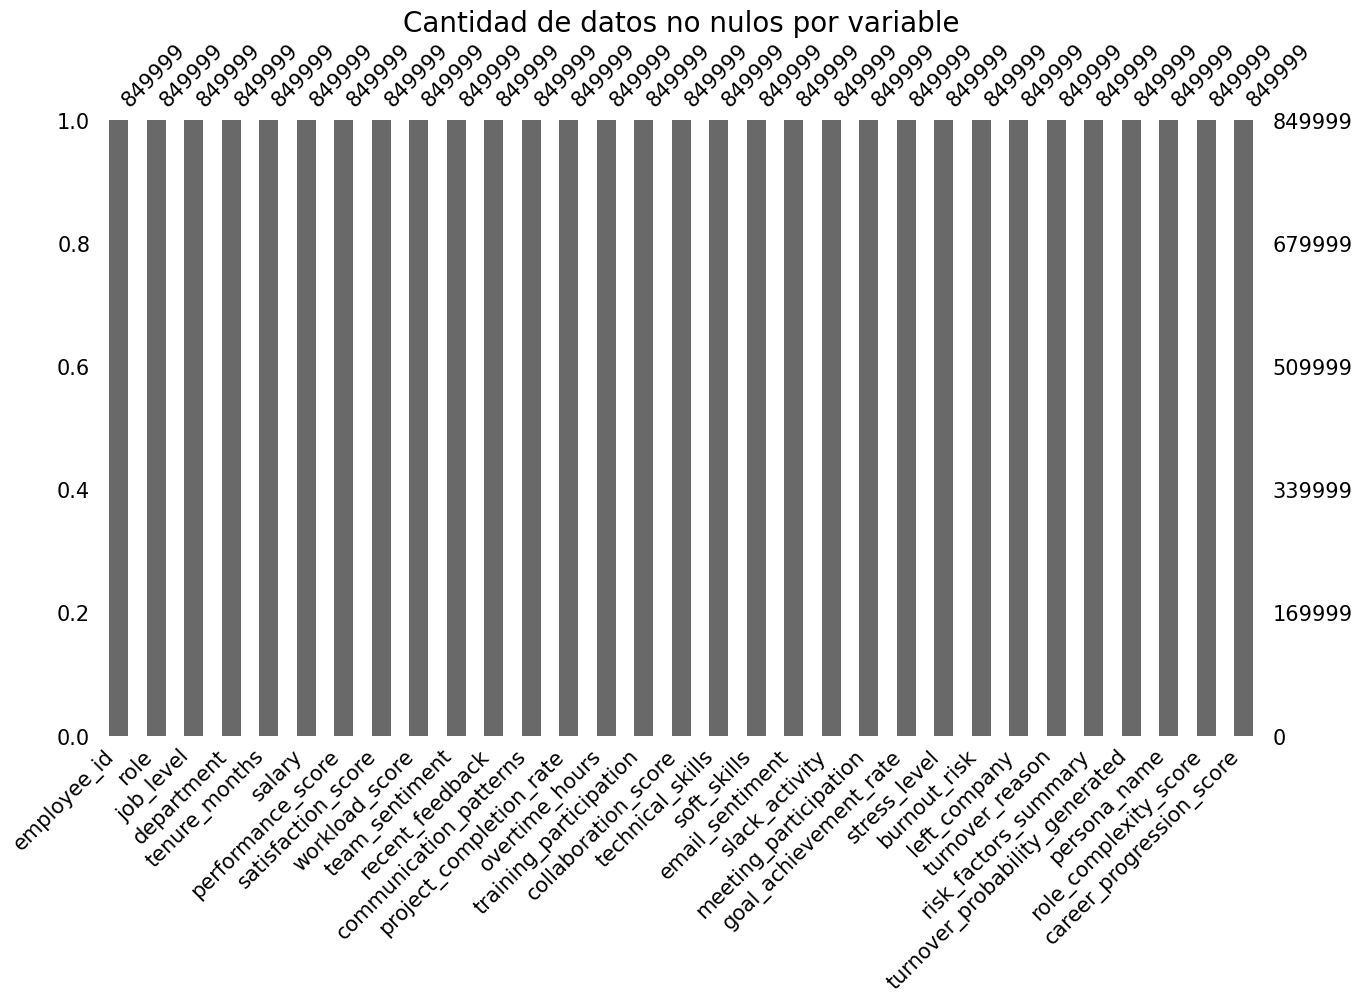

In [85]:
msno.bar(df, fontsize=15, figsize=(15,8))
plt.title("Cantidad de datos no nulos por variable", fontsize=20)
plt.show()

## Exploramos variables categóricas

### role

In [86]:
df["role"].unique()

array([' ', ' Customer Success Manager', ' Administrative Assistant',
       ' Senior Manager', ' Anonymous Employee',
       ' Senior Business Analyst', ' Sales', ' Support Worker',
       ' Customer Advisor', ' Senior Consultant', ' Manager',
       ' Sales Assistant', ' Consultant', ' Team Member',
       ' Project Manager', 'Production Technician I',
       ' Software Development Engineer II', ' Accountant',
       ' Audit Associate', 'Former Employee - Anonymous Employee',
       ' Crew Member/Grill Cook', ' Customer Service Representative',
       ' Crew Member', ' Customer Service Assistant', ' IT Consultant',
       ' Retail Sales Assistant', ' Business Manager',
       ' Research Associate', ' Analyst', ' Tax Associate', ' Lecturer',
       ' Audit Senior Associate', ' Audit Manager', 'Software Engineer',
       ' Operations Analyst', ' Director', ' Assistant Manager',
       ' Housekeeper', ' Software Engineer', ' Specialist',
       'Sales Executive', ' Senior Associate', ' 

In [87]:
df["role"].value_counts()

role
 Anonymous Employee                      224117
                                         109047
Current Employee - Anonymous Employee     21989
 Manager                                  20440
 Consultant                               17308
                                          ...  
 Technical Consultant                       373
 Operations Specialist                      369
 Security Officer                           353
 Actuarial Analyst                          350
 Driver                                     346
Name: count, Length: 300, dtype: int64

In [88]:
df["role"].value_counts().head(10)

role
 Anonymous Employee                      224117
                                         109047
Current Employee - Anonymous Employee     21989
 Manager                                  20440
 Consultant                               17308
 Software Engineer                        14957
Former Employee - Anonymous Employee      14467
 Associate                                14152
 Senior Consultant                        14047
 Analyst                                  13446
Name: count, dtype: int64

### job_level

In [89]:
df["job_level"].unique()

array(['Mid', 'Manager', 'Entry', 'Senior', 'Lead'], dtype=object)

In [90]:
df["job_level"].value_counts()

job_level
Mid        609887
Entry      101211
Manager     78219
Senior      41347
Lead        19335
Name: count, dtype: int64

### department

In [91]:
df["department"].unique()

array(['Research & Development', 'HR', 'Dairy', 'Procurement', 'Meats',
       'Sales & Marketing', 'Technology', 'Operations', 'Sales', 'Legal',
       'Processed Foods', 'R&D', 'Analytics', 'Produce',
       'Customer Service', 'Production       ', 'Bakery', 'Finance',
       'Human Resources', 'Admin Offices', 'nan', 'Store Management',
       'HR Technology', 'IT/IS', 'Software Engineering', 'Audit',
       'Accounts Receiveable', 'Labor Relations', 'Training',
       'Investment', 'Accounting', 'Accounts Payable', 'Compensation',
       'Information Technology', 'Recruitment', 'Executive',
       'Executive Office', 'Employee Records'], dtype=object)

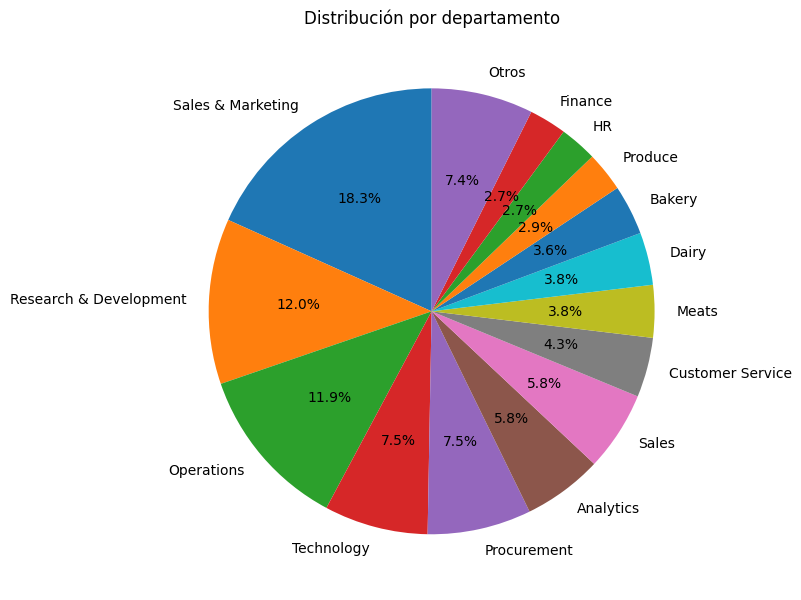

In [92]:
fig, ax = plt.subplots(figsize=(8, 8))
conteos = df["department"].value_counts()
porcentajes = conteos / conteos.sum() * 100

principales = porcentajes[porcentajes >= 2]
otros = porcentajes[porcentajes < 2]
if len(otros) > 0:
    otros_sum = otros.sum()
    datos = pd.concat([principales, pd.Series({"Otros": otros_sum})])
else:
    datos = principales
ax.pie(datos, labels=datos.index, autopct="%1.1f%%", startangle=90)
ax.set_title("Distribución por departamento")
plt.tight_layout()
plt.show()

In [93]:
df["department"].value_counts()

department
Sales & Marketing         155390
Research & Development    101963
Operations                101176
Technology                 64037
Procurement                63979
Analytics                  49011
Sales                      48980
Customer Service           36774
Meats                      32376
Dairy                      32370
Bakery                     30759
Produce                    24426
HR                         23018
Finance                    23011
Processed Foods            15664
Production                 13326
Legal                       9400
R&D                         9228
Human Resources             6569
IT/IS                       2145
nan                          983
Store Management             871
Software Engineering         454
Admin Offices                420
Accounting                   370
Accounts Receiveable         360
Training                     336
Recruitment                  323
Audit                        320
Accounts Payable             317

### recent_feedback (¿Se la considera una categórica?)

In [94]:
df["recent_feedback"].head()

0    Close to home and good shift time given Slow i...
1    HSBC Software Development Pune India Review Gr...
2    Great opportunity for growth if you drink the ...
3    Fabulous people and broad opportunities The ch...
4    The harder you work, the faster you climb. I w...
Name: recent_feedback, dtype: object

### communication_patterns

In [95]:
df["communication_patterns"].unique()

array(['Exhibits communication style typical of a ChangeResistor persona.',
       'Exhibits communication style typical of a NewEnthusiast persona.',
       'Exhibits communication style typical of a OverachievingSprinter persona.',
       'Exhibits communication style typical of a SeasonedExpert persona.',
       'Exhibits communication style typical of a QuietAchiever persona.',
       'Exhibits communication style typical of a SocialCatalyst persona.',
       'Exhibits communication style typical of a StrugglingLearner persona.',
       'Exhibits communication style typical of a SteadyEddy persona.',
       'Exhibits communication style typical of a BurntOutStar persona.',
       'Exhibits communication style typical of a 9-to-5Clockwatcher persona.',
       'Exhibits communication style typical of a CorporateNavigator persona.',
       'Exhibits communication style typical of a AmbitiousClimber persona.'],
      dtype=object)

### technical_skills

In [96]:
unique_technical_skills = df["technical_skills"].explode().dropna().unique()
unique_technical_skills

array(['REST APIs', 'Python (Pandas, NumPy, SciPy)',
       'Linux/Unix Administration', 'PHP (Laravel)', 'R',
       'Machine Learning Theory', 'Docker', 'dbt', 'Network Security',
       'GCP', 'Express.js', 'Angular', 'Node.js', 'CI/CD Pipelines',
       'Ruby on Rails', 'Apache Spark', 'Azure', 'GraphQL',
       'Python (Django, Flask, FastAPI)', 'Vue.js', 'XGBoost',
       'ETL/ELT Pipelines', 'Ansible', 'Data Modeling',
       'Site Reliability Engineering (SRE)', 'NLP', 'JavaScript (ESNext)',
       'Java (Spring Boot)', 'C# (.NET)', 'Statistics',
       'Data Warehousing (Snowflake, BigQuery, Redshift)', 'Webpack',
       'Svelte', 'Rust', 'Kubernetes', 'CSS3',
       'Microservices Architecture', 'HTML5',
       'Deep Learning (TensorFlow, PyTorch)', 'TypeScript', 'AWS',
       'Apache Kafka', 'React', 'Go', 'Airflow', 'Computer Vision',
       'A/B Testing', 'Terraform', 'SQL'], dtype=object)

### soft_skills

In [97]:
unique_soft_skills = df["soft_skills"].explode().dropna().unique()
unique_soft_skills

array(['Communication', 'Creativity', 'Teamwork', 'Conflict Resolution',
       'Mentorship', 'Adaptability', 'Leadership', 'Problem Solving',
       'Critical Thinking', 'Time Management', 'Emotional Intelligence'],
      dtype=object)

### left_company

In [98]:
df['left_company'].value_counts()

left_company
False    607473
True     242526
Name: count, dtype: int64

### turnover_reason

In [99]:
df['turnover_reason'].value_counts()

turnover_reason
Not Applicable                         604246
Burnout / Work-Life Balance            107739
Personal / Relocation                   74178
Compensation / Role Dissatisfaction     34664
Personal Reasons (Anomaly)              12750
Involuntary (Performance)                8896
Career Opportunity                       7526
Name: count, dtype: int64

### risk_factors_summary

In [100]:
df['risk_factors_summary'].value_counts()

risk_factors_summary
Severe Burnout Risk                       489520
Low Risk                                  315695
Anomaly: Overpaid/Underperforming          17000
Low Satisfaction                           13207
Anomaly: High Satisfaction Flight Risk     12493
Low Performance                             2084
Name: count, dtype: int64

### persona_name

In [101]:
df['persona_name'].value_counts()

persona_name
StrugglingLearner        86714
CorporateNavigator       69639
SteadyEddy               69611
NewEnthusiast            69566
QuietAchiever            69525
9-to-5Clockwatcher       69434
ChangeResistor           69337
SeasonedExpert           69293
SocialCatalyst           69273
OverachievingSprinter    69243
BurntOutStar             69209
AmbitiousClimber         69155
Name: count, dtype: int64

## Exploramos variables numéricas

### tenure_months

In [102]:
df["tenure_months"].describe()

count    849999.000000
mean         70.380999
std          50.177033
min           1.000000
25%          30.000000
50%          67.000000
75%         105.000000
max         357.000000
Name: tenure_months, dtype: float64

### salary

In [103]:
df["salary"].describe()

count    849999.000000
mean      84563.069751
std       47444.308564
min       27190.569289
25%       41006.776951
50%       78178.525918
75%      116146.639606
max      384330.428656
Name: salary, dtype: float64

### performance_score

In [104]:
df["performance_score"].describe()

count    849999.000000
mean          0.692027
std           0.183911
min           0.074113
25%           0.571340
50%           0.699235
75%           0.825585
max           1.000000
Name: performance_score, dtype: float64

### satisfaction_score

In [105]:
df["satisfaction_score"].describe()

count    849999.000000
mean          0.581941
std           0.276268
min           0.050000
25%           0.367016
50%           0.583188
75%           0.813912
max           1.000000
Name: satisfaction_score, dtype: float64

### workload_score

In [106]:
df["workload_score"].describe()

count    849999.000000
mean          0.599490
std           0.200038
min           0.006741
25%           0.455657
50%           0.613744
75%           0.756693
max           0.999615
Name: workload_score, dtype: float64

### team_sentiment

In [107]:
df["team_sentiment"].describe()

count    849999.000000
mean          0.666848
std           0.178232
min           0.019774
25%           0.545729
50%           0.686320
75%           0.806540
max           0.999956
Name: team_sentiment, dtype: float64

### project_completion_rate

In [108]:
df["project_completion_rate"].describe()

count    849999.000000
mean          0.595412
std           0.161173
min           0.059290
25%           0.490179
50%           0.609499
75%           0.716149
max           1.000000
Name: project_completion_rate, dtype: float64

### overtime_hours

In [109]:
df["overtime_hours"].describe()

count    849999.000000
mean          3.132903
std           6.094207
min           0.000000
25%           0.000000
50%           0.000000
75%           4.161240
max          73.953574
Name: overtime_hours, dtype: float64

### training_participation

In [110]:
df["training_participation"].describe()

count    849999.000000
mean          0.279344
std           0.221602
min           0.000079
25%           0.103691
50%           0.223123
75%           0.400716
max           1.000000
Name: training_participation, dtype: float64

### collaboration_score

In [111]:
df["collaboration_score"].describe()

count    849999.000000
mean          0.473380
std           0.184961
min           0.008674
25%           0.332366
50%           0.457102
75%           0.600885
max           1.000000
Name: collaboration_score, dtype: float64

### email_sentiment

In [112]:
df["email_sentiment"].describe()

count    849999.000000
mean          0.582392
std           0.277255
min           0.042500
25%           0.367212
50%           0.583141
75%           0.811581
max           1.000000
Name: email_sentiment, dtype: float64

### slack_activity

In [113]:
df["slack_activity"].describe()

count    849999.000000
mean          0.473380
std           0.184961
min           0.008674
25%           0.332366
50%           0.457102
75%           0.600885
max           1.000000
Name: slack_activity, dtype: float64

### meeting_participation

In [114]:
df["meeting_participation"].describe()

count    849999.000000
mean          0.473380
std           0.184961
min           0.008674
25%           0.332366
50%           0.457102
75%           0.600885
max           1.000000
Name: meeting_participation, dtype: float64

### goal_achievement_rate

In [115]:
df["goal_achievement_rate"].describe()

count    849999.000000
mean          0.692027
std           0.183911
min           0.074113
25%           0.571340
50%           0.699235
75%           0.825585
max           1.000000
Name: goal_achievement_rate, dtype: float64

### stress_level

In [116]:
df["stress_level"].describe()

count    849999.000000
mean          0.791048
std           0.264536
min           0.000000
25%           0.613005
50%           0.942151
75%           1.000000
max           1.000000
Name: stress_level, dtype: float64

### burnout_risk

In [117]:
df["burnout_risk"].describe()

count    849999.000000
mean          0.735941
std           0.315756
min           0.000000
25%           0.479950
50%           0.914494
75%           1.000000
max           1.000000
Name: burnout_risk, dtype: float64

### turnover_probability_generated

In [118]:
df["turnover_probability_generated"].describe()

count    849999.000000
mean          0.285327
std           0.087902
min           0.131127
25%           0.227733
50%           0.299657
75%           0.335272
max           0.899983
Name: turnover_probability_generated, dtype: float64

### role_complexity_score

In [119]:
df["role_complexity_score"].describe()

count    849999.000000
mean          0.210859
std           0.085018
min           0.200000
25%           0.200000
50%           0.200000
75%           0.200000
max           1.000000
Name: role_complexity_score, dtype: float64

### career_progression_score

In [120]:
df["career_progression_score"].describe()

count    849999.000000
mean          0.841147
std           0.182216
min           0.182198
25%           0.713997
50%           0.911793
75%           1.000000
max           1.000000
Name: career_progression_score, dtype: float64

## Análisis de datos

### Desempeño y carrera

#### job_level x role_complexity_score

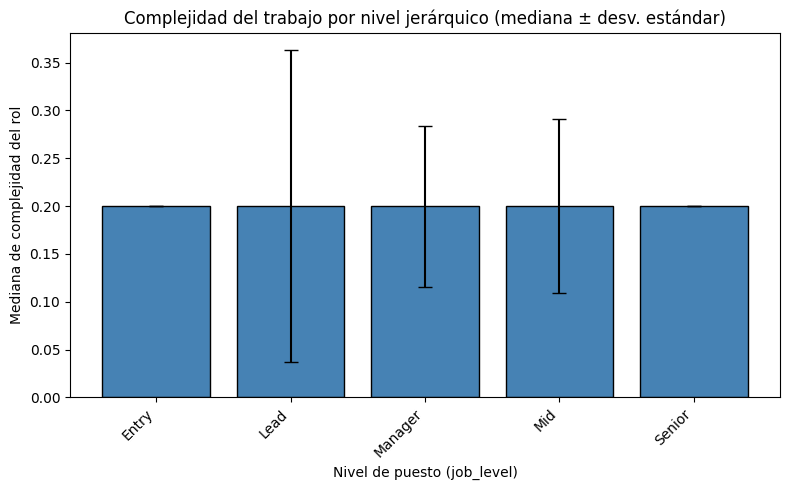

In [121]:
fig, ax = plt.subplots(figsize=(8, 5))
stats = df.groupby("job_level")["role_complexity_score"].agg(["median", "std"]).reset_index()
# Orden opcional: por mediana
stats = stats.sort_values("median", ascending=False)
x = range(len(stats))
ax.bar(x, stats["median"], yerr=stats["std"], capsize=5, color="steelblue", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(stats["job_level"], rotation=45, ha="right")
ax.set_xlabel("Nivel de puesto (job_level)")
ax.set_ylabel("Mediana de complejidad del rol")
ax.set_title("Complejidad del trabajo por nivel jerárquico (mediana ± desv. estándar)")
plt.tight_layout()
plt.show()

#### stress_level x burnout_risk x salary

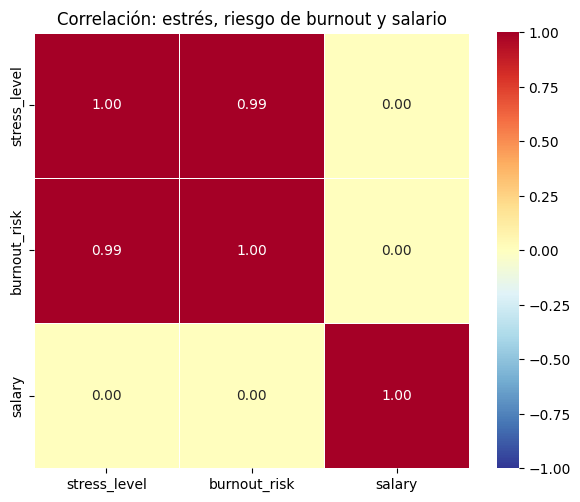

In [122]:
fig, ax = plt.subplots(figsize=(6, 5))
vars_corr = df[["stress_level", "burnout_risk", "salary"]]
corr = vars_corr.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlBu_r", center=0, 
            vmin=-1, vmax=1, square=True, ax=ax, linewidths=0.5)
ax.set_title("Correlación: estrés, riesgo de burnout y salario")
plt.tight_layout()
plt.show()

En el gráfico podemos ver cómo el burnout solo se asocia al nivel de estrés. Es indiferente el sueldo que se cobre.

#### meeting_participation x project_completion_rate

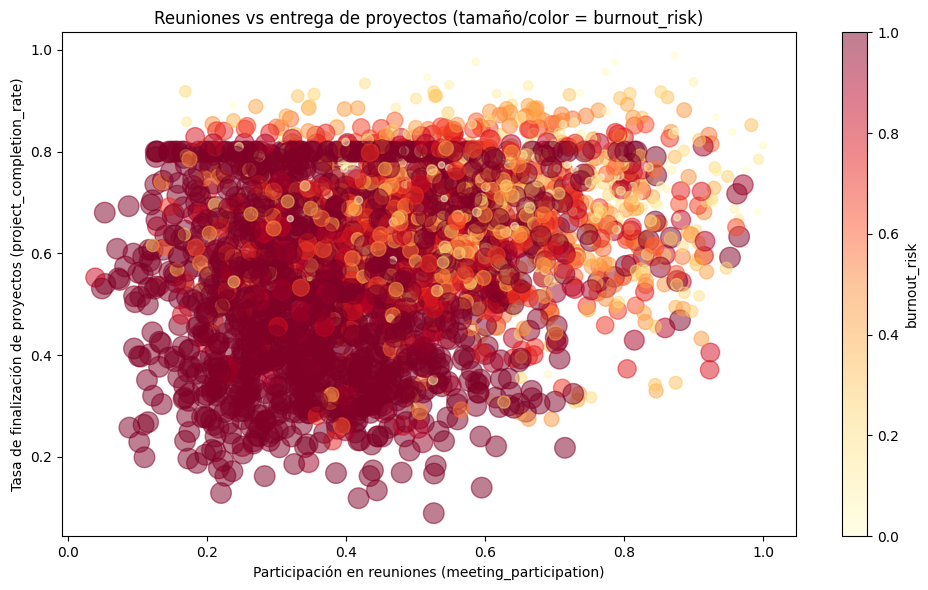

In [123]:
df_bubble = df[["meeting_participation", "project_completion_rate", "burnout_risk"]].dropna().sample(3000, random_state=42)
fig, ax = plt.subplots(figsize=(10, 6))
# Escalar burnout_risk para el tamaño (s en puntos²; escala típica 10–2000)
tam = (df_bubble["burnout_risk"] * 200 + 20)
scatter = ax.scatter(
    df_bubble["meeting_participation"],
    df_bubble["project_completion_rate"],
    s=tam,
    c=df_bubble["burnout_risk"],
    alpha=0.5,
    cmap="YlOrRd",
)
ax.set_xlabel("Participación en reuniones (meeting_participation)")
ax.set_ylabel("Tasa de finalización de proyectos (project_completion_rate)")
ax.set_title("Reuniones vs entrega de proyectos (tamaño/color = burnout_risk)")
plt.colorbar(scatter, label="burnout_risk")
plt.tight_layout()
plt.show()

### Salida y riesgo

#### left_company x department

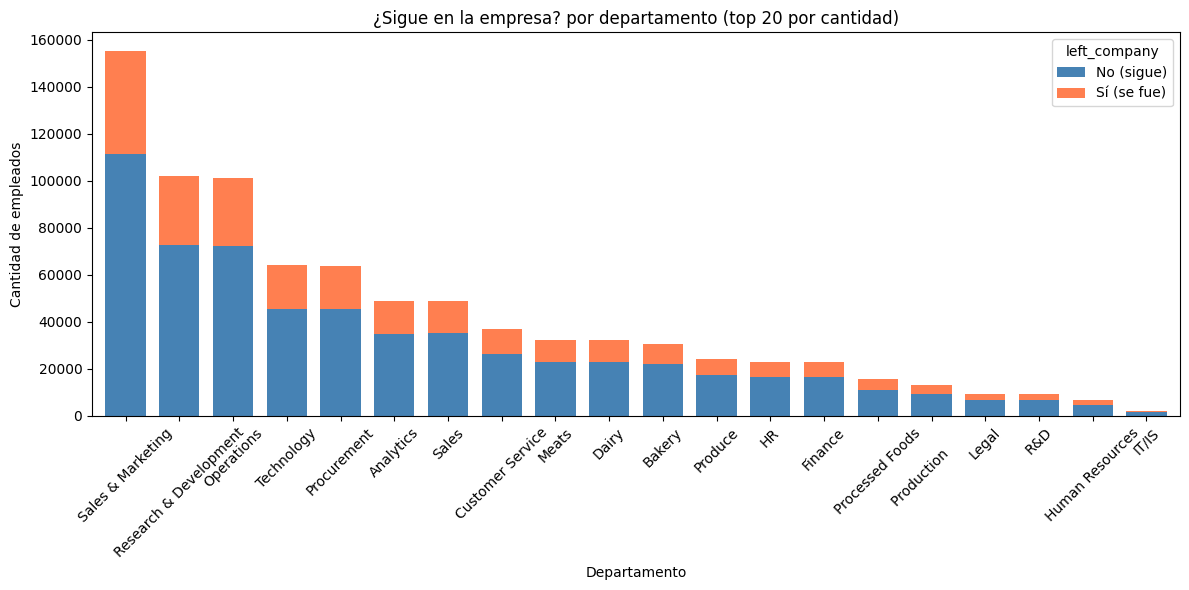

In [124]:
# Top 20 departamentos por cantidad de empleados
top20_depts = df["department"].value_counts().head(20).index
df_top = df[df["department"].isin(top20_depts)]
tab = pd.crosstab(df_top["department"], df_top["left_company"])
# Ordenar por total de empleados (opcional: de mayor a menor)
tab = tab.reindex(df_top["department"].value_counts().head(20).index)
fig, ax = plt.subplots(figsize=(12, 6))
tab.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "coral"], width=0.75)
ax.set_xlabel("Departamento")
ax.set_ylabel("Cantidad de empleados")
ax.set_title("¿Sigue en la empresa? por departamento (top 20 por cantidad)")
ax.legend(title="left_company", labels=["No (sigue)", "Sí (se fue)"])
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

#### turnover_reason

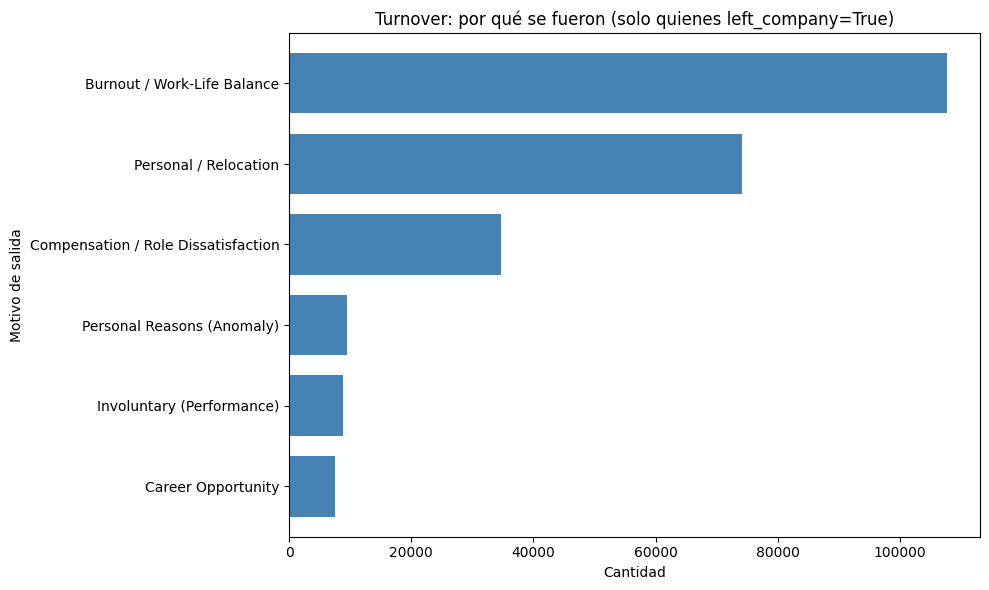

In [125]:
# Bar horizontal: motivos de salida (por cantidad)
conteos = df[df["left_company"]]["turnover_reason"].value_counts()
fig, ax = plt.subplots(figsize=(10, max(6, len(conteos) * 0.35)))
conteos.plot(kind="barh", ax=ax, color="steelblue", width=0.75)
ax.set_xlabel("Cantidad")
ax.set_ylabel("Motivo de salida")
ax.set_title("Turnover: por qué se fueron (solo quienes left_company=True)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

#### recent_feedback x performance_score x burnout risk

/tmp/ipykernel_1262/2099719459.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = df_plot.groupby(["feedback_bin", "performance_bin"])["burnout_risk"].mean().unstack()


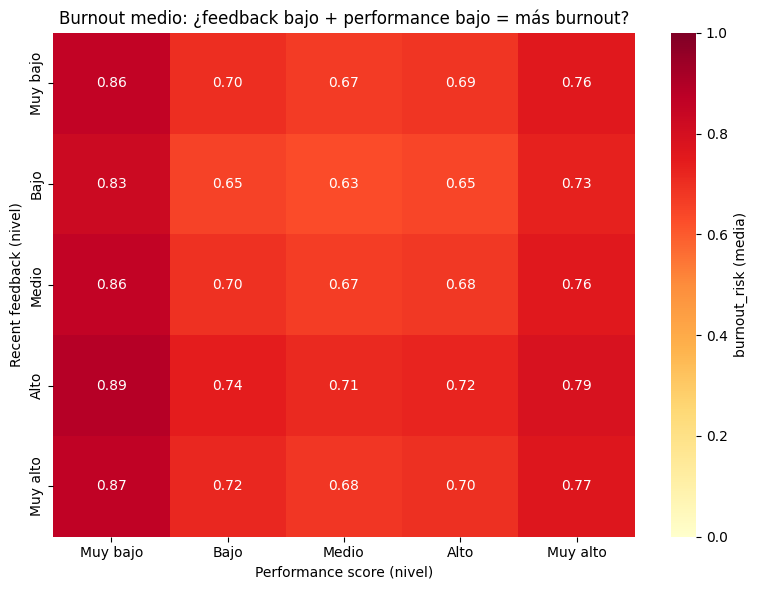

In [126]:
# Bins para feedback y performance
n_bins = 5
df_plot = df.copy()
df_plot["feedback_bin"] = pd.qcut(df_plot["recent_feedback"].rank(method="first"), q=n_bins, labels=["Muy bajo", "Bajo", "Medio", "Alto", "Muy alto"], duplicates="drop")
df_plot["performance_bin"] = pd.qcut(df_plot["performance_score"].rank(method="first"), q=n_bins, labels=["Muy bajo", "Bajo", "Medio", "Alto", "Muy alto"], duplicates="drop")
# Heatmap: en cada celda (feedback × performance) → media de burnout_risk
heatmap_data = df_plot.groupby(["feedback_bin", "performance_bin"])["burnout_risk"].mean().unstack()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1, ax=ax, cbar_kws={"label": "burnout_risk (media)"})
ax.set_xlabel("Performance score (nivel)")
ax.set_ylabel("Recent feedback (nivel)")
ax.set_title("Burnout medio: ¿feedback bajo + performance bajo = más burnout?")
plt.tight_layout()
plt.show()